In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Data generation (handle from exact solution - no need to handle the discontinuity)

-, Step 1: Different $u$ -> Different $u_t$. (u function space) \
-, Step 2: Creating Dataset Different $u$ -> Different $u_t$  => Operator Learning Dataset for original Neural Operator & Lifted Neural Operator \
-, Step 3: Identify the discontinuity locating of $u_t$ \
-, Step 4: Creating Dataset Different $u$ -> $\textit{discontinuity\_locating\_t}$  => Cutting Net Dataset

#### Step 1: u_0 -> u_t

In [2]:
# ------------------------- Initial condition, Setting for u_0 ------------------------ 
def random_initial_condition_u_0_one_discontinuities(x, Nx):
    u_0 = np.zeros(Nx)

    x_discontinuity_1, mag_1 = np.round(np.random.uniform(-0.9, -0.1), 2), np.round(np.random.uniform(1, 2), 1) # 81 cases for x, 11 cases for mag, total 81*11=891 cases
    
    u_0[x < x_discontinuity_1] = mag_1
    u_0[x >= x_discontinuity_1] = 0.0
    return x_discontinuity_1, mag_1, u_0

# ------------------------ Exact solution for inviscid Burgers shock ------------------------
def burgers_exact_solution_shock(x, t_domain, x_discontinuity_1, mag_1):
    Nt, Nx = len(t_domain), len(x)
    u_t = np.zeros((Nt, Nx))

    uL = mag_1
    uR = 0.0
    s = 0.5 * (uL + uR)   # shock speed = mag_1 / 2

    for n, t in enumerate(t_domain):
        x_shock = x_discontinuity_1 + s * t
        u_t[n, x < x_shock] = uL
        u_t[n, x >= x_shock] = uR

    return u_t

#### Step 2: Operator Learning Dataset for Neural Operator & Lifted Neural Operator (Different u -> Different u_t)

In [3]:
# Domain
Nx = 1000
x = np.linspace(-1, 1, Nx)
dx = x[1] - x[0]

T, dt = 0.5, 0.0005
t_domain = np.arange(0, T, dt)

# ------------------------ Generate dataset ------------------------
N = 250  # number of datasets to generate => 20% or the total 891 cases   

input_data, output_data = [], []
for i in range(N):
    x_discontinuity, mag, u_0 = random_initial_condition_u_0_one_discontinuities(x, Nx)
    u_t = burgers_exact_solution_shock(x, t_domain, x_discontinuity, mag)

    input_data.append(u_0)
    output_data.append(u_t)

In [4]:
np.savez(
    f"exact_solution_dataset_N_{N}_one_discontinuity.npz",
    X=np.array(input_data),     # (N, Nx)
    Y=np.array(output_data),    # (N, Nt, Nx)
    x=x,                        # (Nx,)
    t=t_domain                  # (Nt,)
)

### Step 3: Locating discontinuities

In [5]:
# ------------------- Filter out the high derivatives by percentile threshold -----------------------
def high_derivative_points(du_dx_t, discon_number = 1):
    discontinuity_idx_t = [np.argpartition(np.abs(du_dx_k), -discon_number)[-discon_number:] for du_dx_k in du_dx_t]
    return discontinuity_idx_t

discontinuity_t_all = []
for u_t in output_data:
    du_dx_t = [np.gradient(u, x) for u in u_t]

    discontinuity_idx_t = high_derivative_points(du_dx_t, discon_number=1)
    x_discontinuity = x[discontinuity_idx_t]
    discontinuity_t_all.append(x_discontinuity)

print(len(discontinuity_t_all), len(discontinuity_t_all[0]), len(discontinuity_t_all[0][0]))

250 1000 1


#### Step 4: Cutting Net Dataset - Different u_0 -> Discontinuity_location

In [6]:
np.savez(
    f"exact_solution_discontinuity_dataset_N_{N}_one_discontinuity.npz",
    X=np.array(input_data),                            # (N, Nx)
    Y=np.array(discontinuity_t_all),                   # (N, Nt, discontinuities_location) - if we have a fixed number of discontinuities
    x=x,                                               # (Nx,)
    t=t_domain                                         # (Nt,)
)

## Plotting

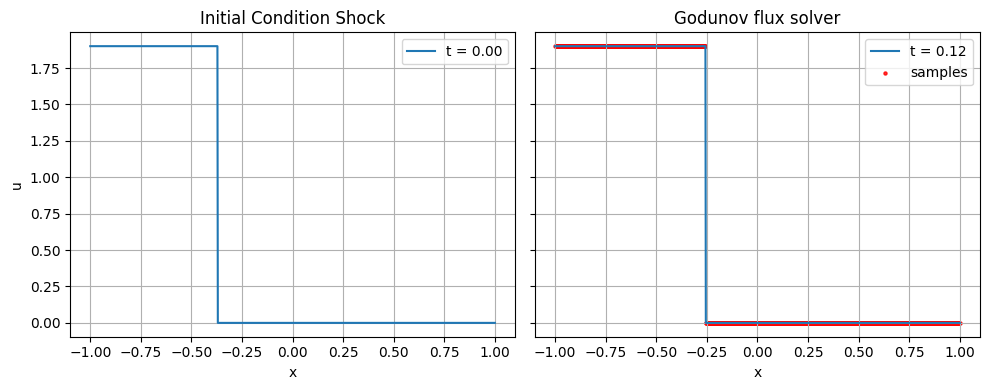

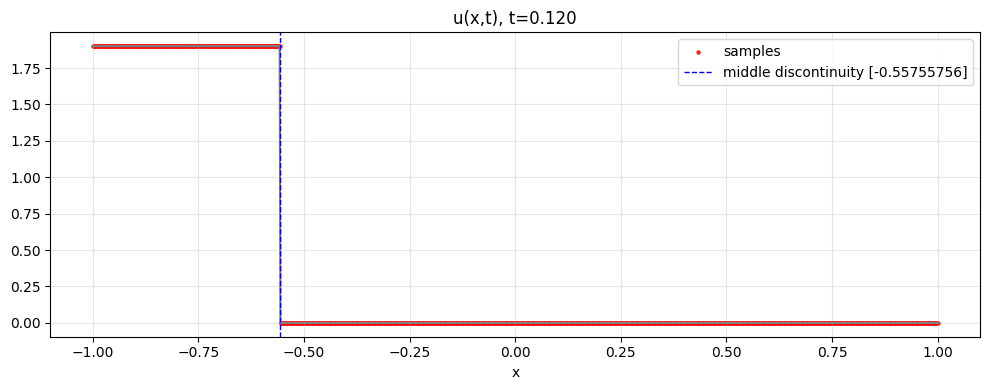

In [7]:
def plot_solution(x, u_0, u_t, t_plot,dt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    ax1.plot(x, u_0, label="t = 0.00")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u")
    ax1.set_title("Initial Condition Shock")
    ax1.legend()
    ax1.grid()

    ax2.plot(x, u_t[int(t_plot/dt)], label="t = %.2f" % t_plot)
    ax2.scatter(x, u_t[int(t_plot/dt)], color='red', s=5, label="samples", alpha=0.8)
    ax2.set_xlabel("x")
    ax2.set_title("Godunov flux solver")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

def plotting_discontinuity_area(x, u_t, x_discontinuity, t_plot, dt):
    k = min(int(t_plot / dt), len(u_t) - 1)

    plt.figure(figsize=(10, 4))
    plt.plot(x, u_t[k], color="gray")
    plt.scatter(x, u_t[k], color="red", s=5, alpha=0.8, label="samples")
    plt.axvline(x_discontinuity[k], color='blue', linestyle='--', linewidth=1, label=f"middle discontinuity {x_discontinuity[k]}")
    plt.title(f"u(x,t), t={k*dt:.3f}")
    plt.xlabel("x")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

t_plot = 0.12
plot_solution(x, input_data[0], output_data[0], t_plot=t_plot, dt=dt)
plotting_discontinuity_area(x, u_t, x_discontinuity, t_plot=t_plot, dt=dt)